# Day 12: Garden Groups 
---
```
Why not search for the Chief Historian near the gardener and his massive farm? There's plenty of food, so The Historians grab something to eat while they search.

You're about to settle near a complex arrangement of garden plots when some Elves ask if you can lend a hand. They'd like to set up fences around each region of garden plots, but they can't figure out how much fence they need to order or how much it will cost. They hand you a map (your puzzle input) of the garden plots.

Each garden plot grows only a single type of plant and is indicated by a single letter on your map. When multiple garden plots are growing the same type of plant and are touching (horizontally or vertically), they form a region. For example:

AAAA
BBCD
BBCC
EEEC
This 4x4 arrangement includes garden plots growing five different types of plants (labeled A, B, C, D, and E), each grouped into their own region.

In order to accurately calculate the cost of the fence around a single region, you need to know that region's area and perimeter.

The area of a region is simply the number of garden plots the region contains. The above map's type A, B, and C plants are each in a region of area 4. The type E plants are in a region of area 3; the type D plants are in a region of area 1.

Each garden plot is a square and so has four sides. The perimeter of a region is the number of sides of garden plots in the region that do not touch another garden plot in the same region. The type A and C plants are each in a region with perimeter 10. The type B and E plants are each in a region with perimeter 8. The lone D plot forms its own region with perimeter 4.

Visually indicating the sides of plots in each region that contribute to the perimeter using - and |, the above map's regions' perimeters are measured as follows:

+-+-+-+-+
|A A A A|
+-+-+-+-+     +-+
              |D|
+-+-+   +-+   +-+
|B B|   |C|
+   +   + +-+
|B B|   |C C|
+-+-+   +-+ +
          |C|
+-+-+-+   +-+
|E E E|
+-+-+-+
Plants of the same type can appear in multiple separate regions, and regions can even appear within other regions. For example:

OOOOO
OXOXO
OOOOO
OXOXO
OOOOO
The above map contains five regions, one containing all of the O garden plots, and the other four each containing a single X plot.

The four X regions each have area 1 and perimeter 4. The region containing 21 type O plants is more complicated; in addition to its outer edge contributing a perimeter of 20, its boundary with each X region contributes an additional 4 to its perimeter, for a total perimeter of 36.

Due to "modern" business practices, the price of fence required for a region is found by multiplying that region's area by its perimeter. The total price of fencing all regions on a map is found by adding together the price of fence for every region on the map.

In the first example, region A has price 4 * 10 = 40, region B has price 4 * 8 = 32, region C has price 4 * 10 = 40, region D has price 1 * 4 = 4, and region E has price 3 * 8 = 24. So, the total price for the first example is 140.

In the second example, the region with all of the O plants has price 21 * 36 = 756, and each of the four smaller X regions has price 1 * 4 = 4, for a total price of 772 (756 + 4 + 4 + 4 + 4).

Here's a larger example:

RRRRIICCFF
RRRRIICCCF
VVRRRCCFFF
VVRCCCJFFF
VVVVCJJCFE
VVIVCCJJEE
VVIIICJJEE
MIIIIIJJEE
MIIISIJEEE
MMMISSJEEE
It contains:

A region of R plants with price 12 * 18 = 216.
A region of I plants with price 4 * 8 = 32.
A region of C plants with price 14 * 28 = 392.
A region of F plants with price 10 * 18 = 180.
A region of V plants with price 13 * 20 = 260.
A region of J plants with price 11 * 20 = 220.
A region of C plants with price 1 * 4 = 4.
A region of E plants with price 13 * 18 = 234.
A region of I plants with price 14 * 22 = 308.
A region of M plants with price 5 * 12 = 60.
A region of S plants with price 3 * 8 = 24.
So, it has a total price of 1930.
```
What is the total price of fencing all regions on your map?

In [1]:
import re
import sys
import numpy as np
sys.path.append("..")

from common_processing import read_as_character_array
from scipy.ndimage import convolve
from skimage.measure import label

test_path = "test.txt"
data_path = "data.txt"

In [2]:
class Day12:
    def __init__(self, data_file):
        self.map = read_as_character_array(data_file)
        self.unique_plants = np.unique(self.map)
        pass

    def _create_masked_array(self, plant: str) -> np.array:
        """ 
        Returns an array with self.map.shape, with a 0 where
        self.map is equal to plant and 1 elsewhere
        """
        return np.where(self.map == plant, 1, 0)
    
    def _boundary_convolution(self, plant: str) -> np.array:
        """ 
        Gets the convolution between the edge-counting array 
        and the class of plant. remove negative values for pixels
        just outside the boundary
        """
        edge_counting_kernel = np.array([
                0, -1, 0,
                -1, 4, -1,
                0, -1, 0,
        ]).reshape(3,3)

        masked_array = self._create_masked_array(plant)
        convolution = convolve(masked_array, edge_counting_kernel, mode="constant", cval=0)
        return np.where(convolution > 0, convolution, 0)
    
    def _get_boundary_sum(self, plant) -> int:
        """
        Get the total boundary for a given plant
        """
        convolution = self._boundary_convolution(plant)
        return int(np.sum(convolution))
    
    def _count_area(self, plant: str) -> int :
        """ 
            For the given map, get the area of each unique plant
        """
        masked_array = self._create_masked_array(plant)
        
        return int(np.sum(masked_array))
    
    def _rename_clusters(self, plant):
        """ 
        Check if there are more than 1 plot for a given plant
        if there are, rename the map with 'plant1', 'plant2', ... 
        """

        masked_array = self._create_masked_array(plant)
        labeled_mask = label(masked_array, connectivity=1)

        if np.max(labeled_mask) > 1:
            self._replace_map(labeled_mask)
        pass

    def _replace_map(self, labeled_mask: np.array):
        """ 
        Replace the map characters with and added string
        with the number in the labeled mask
        """
        labeled_mask = labeled_mask.astype(str)

        self.map = self.map + label(labeled_mask).astype(str)

        remove_leading_zeros = np.vectorize(lambda x: x.removesuffix("0"))
        
        self.map = remove_leading_zeros(self.map)
        pass 

day12 = Day12(test_path)

In [8]:
# Initialy: without discriminating for the same plant in diferent plots, get total area and total perimeter per plant
day12 = Day12(test_path)

# Pre-process the map to separate individual plots:
print(day12.map)
for plant in day12.unique_plants:
    day12._rename_clusters(plant)
day12.unique_plants = np.unique(day12.map)
print(" ")
print(day12.map)

results = {
    plant: (day12._count_area(plant), day12._get_boundary_sum(plant)) 
    for plant in day12.unique_plants
}
print(results)



[['R' 'R' 'R' 'R' 'I' 'I' 'C' 'C' 'F' 'F']
 ['R' 'R' 'R' 'R' 'I' 'I' 'C' 'C' 'C' 'F']
 ['V' 'V' 'R' 'R' 'R' 'C' 'C' 'F' 'F' 'F']
 ['V' 'V' 'R' 'C' 'C' 'C' 'J' 'F' 'F' 'F']
 ['V' 'V' 'V' 'V' 'C' 'J' 'J' 'C' 'F' 'E']
 ['V' 'V' 'I' 'V' 'C' 'C' 'J' 'J' 'E' 'E']
 ['V' 'V' 'I' 'I' 'I' 'C' 'J' 'J' 'E' 'E']
 ['M' 'I' 'I' 'I' 'I' 'I' 'J' 'J' 'E' 'E']
 ['M' 'I' 'I' 'I' 'S' 'I' 'J' 'E' 'E' 'E']
 ['M' 'M' 'M' 'I' 'S' 'S' 'J' 'E' 'E' 'E']]
 
[['R' 'R' 'R' 'R' 'I1' 'I1' 'C1' 'C1' 'F' 'F']
 ['R' 'R' 'R' 'R' 'I1' 'I1' 'C1' 'C1' 'C1' 'F']
 ['V' 'V' 'R' 'R' 'R' 'C1' 'C1' 'F' 'F' 'F']
 ['V' 'V' 'R' 'C1' 'C1' 'C1' 'J' 'F' 'F' 'F']
 ['V' 'V' 'V' 'V' 'C1' 'J' 'J' 'C2' 'F' 'E']
 ['V' 'V' 'I2' 'V' 'C1' 'C1' 'J' 'J' 'E' 'E']
 ['V' 'V' 'I2' 'I2' 'I2' 'C1' 'J' 'J' 'E' 'E']
 ['M' 'I2' 'I2' 'I2' 'I2' 'I2' 'J' 'J' 'E' 'E']
 ['M' 'I2' 'I2' 'I2' 'S' 'I2' 'J' 'E' 'E' 'E']
 ['M' 'M' 'M' 'I2' 'S' 'S' 'J' 'E' 'E' 'E']]
{np.str_('C1'): (14, 28), np.str_('C2'): (1, 4), np.str_('E'): (13, 18), np.str_('F'): (10, 18), np.str

In [10]:
# Get the sum of the product area x perimeter
total = 0
for cluster, values in results.items():
    total += values[0] * values[1]
print(total)

1930


In [ ]:
# IDEAS:
"""
1st: identify boundaries: 

First idea: use BW distance:

for every unique letter, compute a map that is 1 where that letter is, and 0 elsewere
compute Black-White disctance (ed)
Boundary letters have a distance of 1

"""
from scipy.ndimage import distance_transform_edt

""" 
It's hard not to think about building graphs. but they take matrices and thus are O(n^2) ... 

for each unique letter:
    get the masked map. 
    cluster/construct a non-connected graph and identify
    each component.

        The number of nodes is the area


"""

""" 
Brute force method:

run the matrix element by element checking if the characters next to it are equal and create
a boundary if not (also handle the edge of the matrix)

"""

## Simplify the problem:
""" 
What if I didnt need to separate regions:

get the count of unique letters (that's the area)

compute a mask of each letter (0 for letter, 1 for non-equal letter)

run each mask and:
    for each letter, check the boundaries with a 3x3 kernel:
    [ 
        0, 1, 0,
        1, 0, 1,
        0, 1, 0,
    ]

    The total boundary is the sum of this kernel over the black and white mask

    meaning, for a each (i,j) element of the masked array, compute elementwhise product of

    [
       (i-1, j-1), (i-1, j), (i-1, j+1),
       (i, j-1),   (i, j),   (i, j+1),
       (i+1, j-1), (i+1, j), (i+1, j+1),
    ]
    and the kernel 
    [ 
        0, 1, 0,
        1, 0, 1,
        0, 1, 0,
    ]

    then the boundary contribution of this element is the sum of all the elements of the product.

    scipy.convolve

"""

In [ ]:
# Do with the full data:
day12 = Day12(data_path)

# Pre-process the map to separate individual plots:
for plant in day12.unique_plants:
    day12._rename_clusters(plant) # NOTE this produces different clusters form labeling the whole map first

day12.unique_plants = np.unique(day12.map)

results = {
    plant: (day12._count_area(plant), day12._get_boundary_sum(plant)) 
    for plant in day12.unique_plants
}

# Get the sum of the product area x perimeter
total = 0
for cluster, values in results.items():
    total += values[0] * values[1]
print(total)

print(len(day12.unique_plants))

1498108
565


In [21]:
# check the number of regions:

day12 = Day12(data_path)

# Transform the original map into an integer array
v_ord = np.vectorize(lambda x: ord(x))

np.max(label(v_ord(day12.map)))

np.int64(604)

##  This is too high, not the right answer 
1534404  

1498108 (label connectivity = 1 ) still too high

NOTE: the number of clusters with label (ord(map)) and the obtained with the pipeline is not the same

In [51]:
# FIX: re-label the map all at the same time using python's ord()

day12 = Day12(data_path)
v_ord = np.vectorize(lambda x: ord(x))
labeled_map = label(v_ord(day12.map))

day12.map = labeled_map
day12.unique_plants = np.unique(labeled_map)

results = {
    plant: (day12._count_area(plant), day12._get_boundary_sum(plant)) 
    for plant in day12.unique_plants
}

# Get the sum of the product area x perimeter
total = 0
for cluster, values in results.items():
    total += values[0] * values[1]
print(total)


1410874


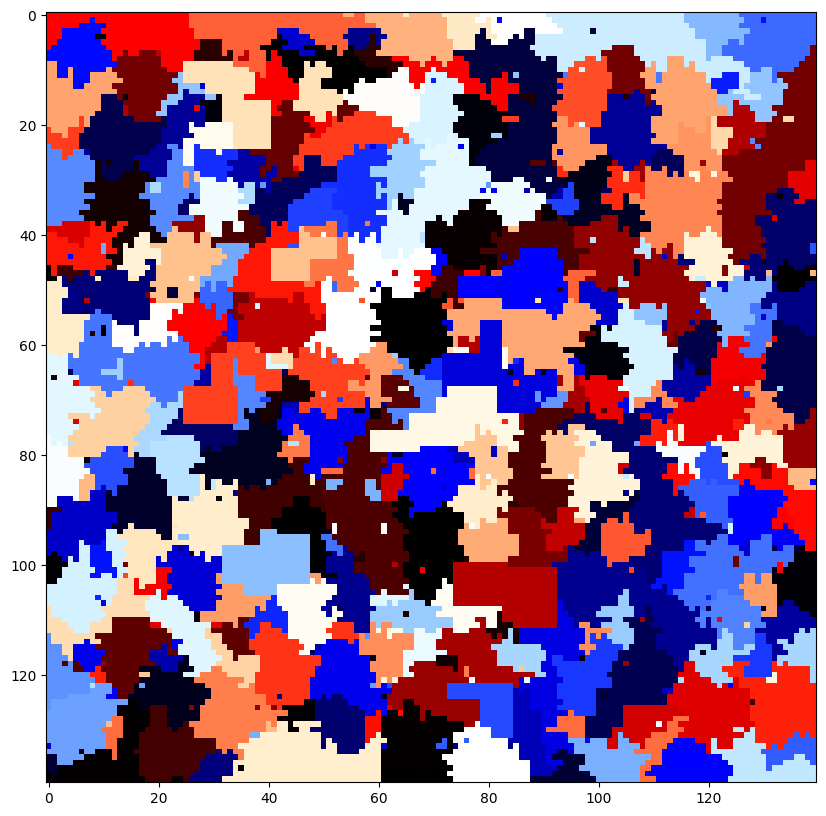

In [60]:
import matplotlib.pyplot as plt 
fig, ax = plt.subplots(1,1, figsize = (10,10))
ax.imshow(day12.map, cmap="flag")

## This is ALSO too high
1410874  

no idea why this works for every example but not for the full image ... 
